In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv("Downloads/digital_payment_behavior_clustering_dataset.csv")

In [3]:
df.head()

,user_id,city,device_type,kyc_level,account_age_months,account_age_band,active_days_per_month,transactions_per_day,monthly_transaction_count,avg_transaction_amount,...,night_txn_ratio,weekend_txn_ratio,session_count,app_open_frequency,avg_session_duration_min,avg_gap_between_txn_hours,spend_volatility,avg_balance_before_txn,cashback_usage_ratio,suspicious_activity_score
0,UPI00001,Mumbai,Android,Minimum,28,2y+,17,5.12,109,246.96,...,0.073,0.321,66,111,2.14,3.72,0.359,5464.53,0.333,26.91
1,UPI00002,Chennai,Android,Premium,11,6-12m,14,1.55,20,517.36,...,0.113,0.292,33,50,4.18,31.47,0.476,2894.69,0.327,13.03
2,UPI00003,Pune,Android,Premium,31,2y+,17,3.96,54,894.50,...,0.102,0.365,31,41,6.20,12.27,0.409,7560.72,0.279,32.01
3,UPI00004,Chennai,Android,Minimum,14,1-2y,11,9.99,110,1358.09,...,0.614,0.598,41,117,9.17,4.02,0.535,47098.46,0.373,77.72
4,UPI00005,Ahmedabad,Android,Full,29,2y+,16,11.99,167,493.71,...,0.553,0.448,44,84,7.42,3.23,0.847,55402.11,0.310,78.22


In [4]:
df.tail()

,user_id,city,device_type,kyc_level,account_age_months,account_age_band,active_days_per_month,transactions_per_day,monthly_transaction_count,avg_transaction_amount,...,night_txn_ratio,weekend_txn_ratio,session_count,app_open_frequency,avg_session_duration_min,avg_gap_between_txn_hours,spend_volatility,avg_balance_before_txn,cashback_usage_ratio,suspicious_activity_score
4995,UPI04996,Pune,Android,Minimum,8,6-12m,18,4.48,67,940.73,...,0.125,0.267,58,74,6.14,7.15,0.453,18684.33,0.495,22.53
4996,UPI04997,Chennai,Android,Full,17,1-2y,24,7.28,193,181.42,...,0.102,0.348,86,174,8.39,1.80,0.459,20604.92,0.277,28.53
4997,UPI04998,Chennai,Android,Premium,19,1-2y,15,5.68,93,888.96,...,0.085,0.209,30,50,7.19,8.87,0.465,53699.90,0.460,18.29
4998,UPI04999,Delhi,Android,Full,10,6-12m,16,2.87,30,629.53,...,0.096,0.383,36,50,5.61,22.94,0.455,11948.49,0.347,54.02
4999,UPI05000,Chennai,Android,Premium,1,0-6m,11,3.99,21,1124.25,...,0.523,0.642,28,82,7.32,29.80,0.665,3160.98,0.282,100.00


In [5]:
df.isnull().sum()

user_id                      0
city                         0
device_type                  0
kyc_level                    0
account_age_months           0
account_age_band             0
active_days_per_month        0
transactions_per_day         0
monthly_transaction_count    0
avg_transaction_amount       0
max_transaction_amount       0
total_monthly_spend          0
merchant_txn_ratio           0
peer_txn_ratio               0
merchant_count_month         0
peer_count_month             0
failed_transactions          0
failed_txn_ratio             0
refund_requests              0
refund_ratio                 0
night_txn_ratio              0
weekend_txn_ratio            0
session_count                0
app_open_frequency           0
avg_session_duration_min     0
avg_gap_between_txn_hours    0
spend_volatility             0
avg_balance_before_txn       0
cashback_usage_ratio         0
suspicious_activity_score    0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    5000 non-null   object 
 1   city                       5000 non-null   object 
 2   device_type                5000 non-null   object 
 3   kyc_level                  5000 non-null   object 
 4   account_age_months         5000 non-null   int64  
 5   account_age_band           5000 non-null   object 
 6   active_days_per_month      5000 non-null   int64  
 7   transactions_per_day       5000 non-null   float64
 8   monthly_transaction_count  5000 non-null   int64  
 9   avg_transaction_amount     5000 non-null   float64
 10  max_transaction_amount     5000 non-null   float64
 11  total_monthly_spend        5000 non-null   float64
 12  merchant_txn_ratio         5000 non-null   float64
 13  peer_txn_ratio             5000 non-null   float

In [7]:
df.describe()

,account_age_months,active_days_per_month,transactions_per_day,monthly_transaction_count,avg_transaction_amount,max_transaction_amount,total_monthly_spend,merchant_txn_ratio,peer_txn_ratio,merchant_count_month,...,night_txn_ratio,weekend_txn_ratio,session_count,app_open_frequency,avg_session_duration_min,avg_gap_between_txn_hours,spend_volatility,avg_balance_before_txn,cashback_usage_ratio,suspicious_activity_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,17.557000,17.132200,4.571854,86.359400,953.655104,2621.210372,69926.961856,0.618921,0.381818,44.459400,...,0.155231,0.334804,44.68380,77.741000,5.137040,38.024910,0.376452,29765.524854,0.353066,38.125814
std,9.532037,7.441411,2.923244,68.038231,1124.154102,3233.049224,102386.040608,0.167068,0.171862,36.457276,...,0.140532,0.097757,26.04843,53.941623,2.059052,68.963554,0.165912,47254.856718,0.069424,23.971917
min,1.000000,1.000000,0.050000,1.000000,20.000000,27.370000,100.000000,0.200000,0.020000,0.000000,...,0.020000,0.180000,2.00000,3.000000,0.500000,0.200000,0.050000,50.000000,0.156000,1.000000
25%,11.000000,12.000000,2.460000,32.000000,244.002500,645.757500,13757.080000,0.507000,0.270000,15.000000,...,0.078000,0.260750,26.00000,38.000000,3.740000,5.627500,0.263000,4422.320000,0.305000,22.315000
50%,17.000000,18.000000,4.220000,75.000000,560.230000,1409.420000,35892.485000,0.608000,0.390000,38.000000,...,0.120000,0.323500,44.00000,69.000000,4.970000,10.160000,0.362000,13714.065000,0.352000,30.205000
75%,24.000000,23.000000,6.130000,127.000000,992.730000,2815.885000,78350.982500,0.715000,0.492000,66.000000,...,0.164000,0.382250,62.00000,108.000000,6.320000,22.675000,0.474000,32667.917500,0.400000,44.032500
max,58.000000,31.000000,20.110000,440.000000,7057.300000,22554.740000,900000.000000,0.959000,0.850000,225.000000,...,0.778000,0.700000,142.00000,340.000000,16.540000,250.000000,1.140000,350000.000000,0.559000,100.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [10]:
numrical= df.select_dtypes(include=['int64','float64']).columns.tolist()

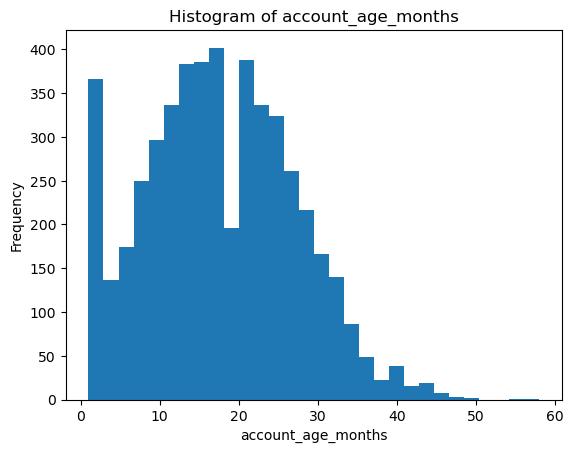

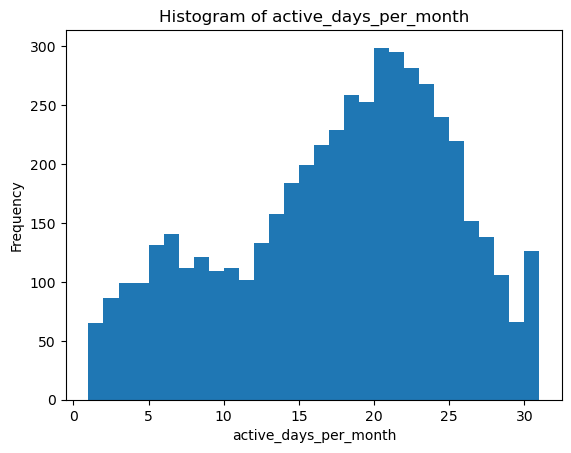

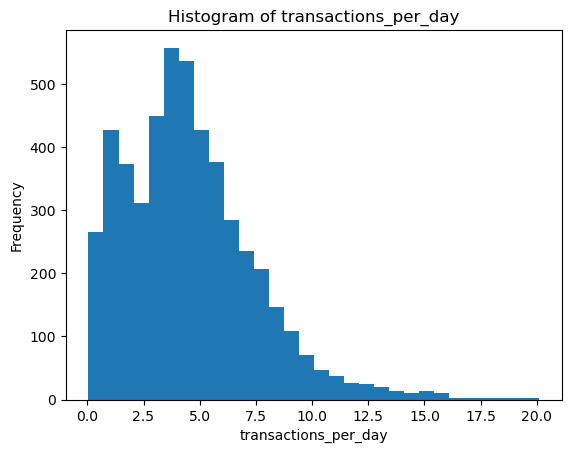

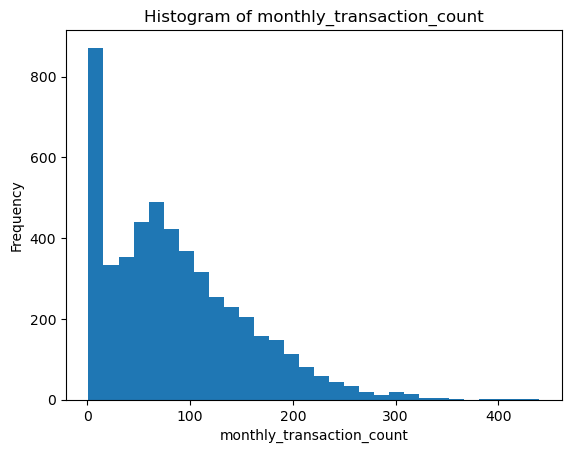

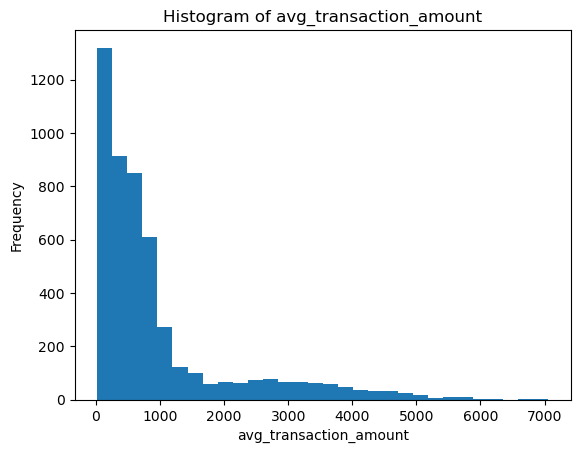

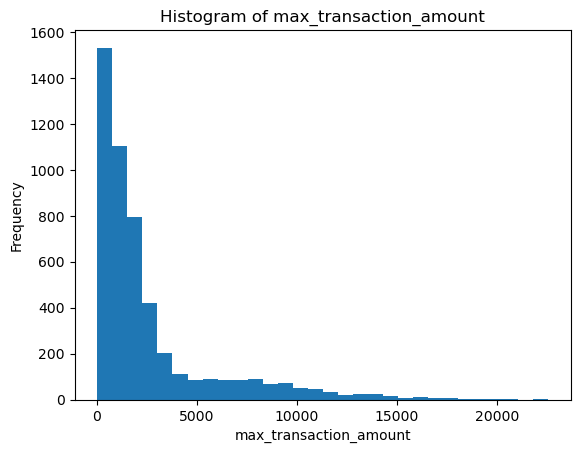

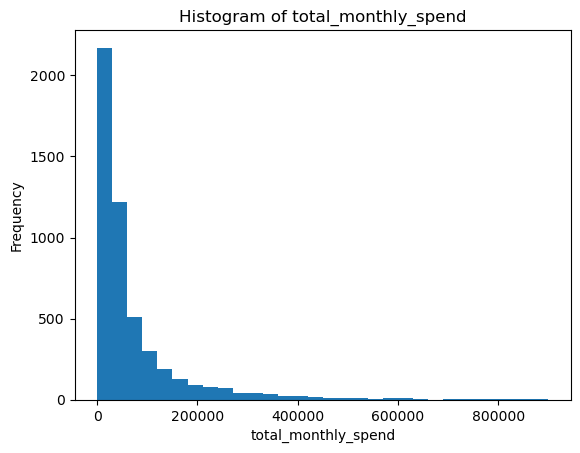

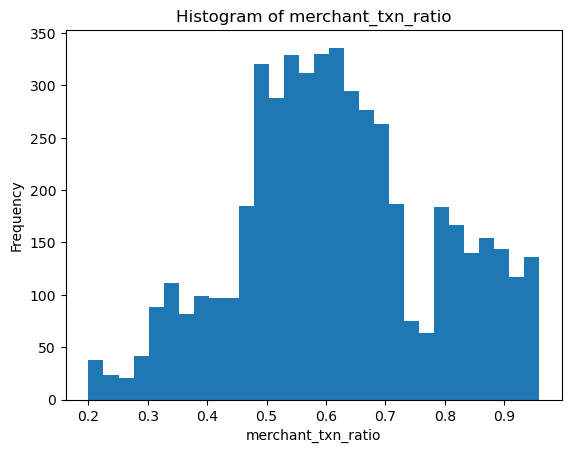

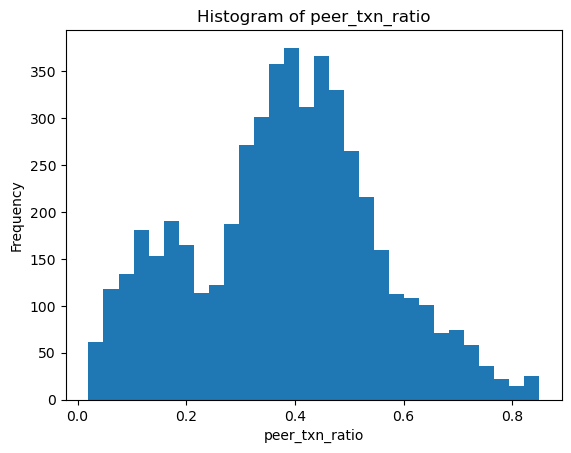

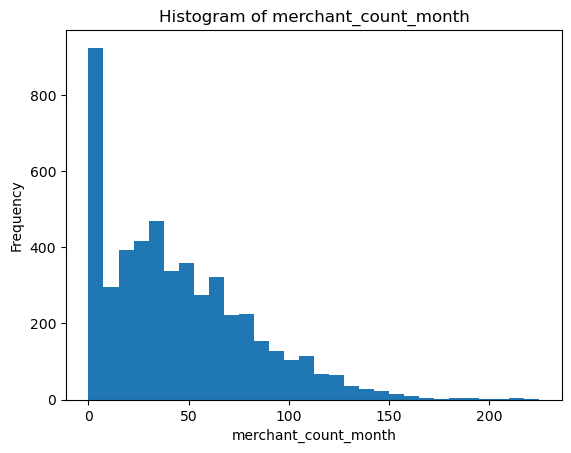

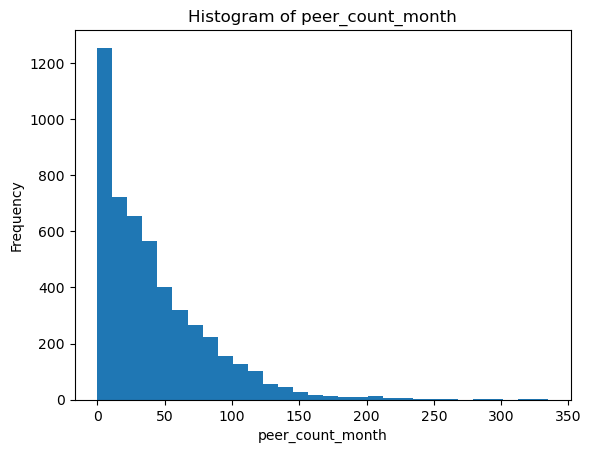

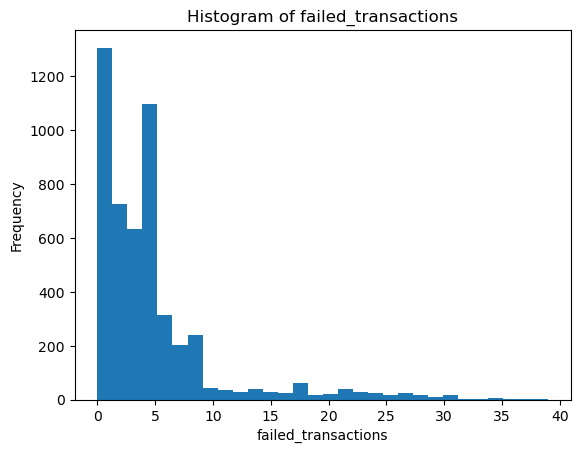

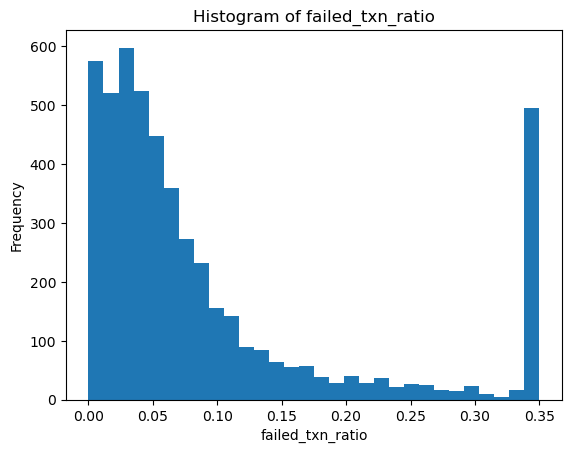

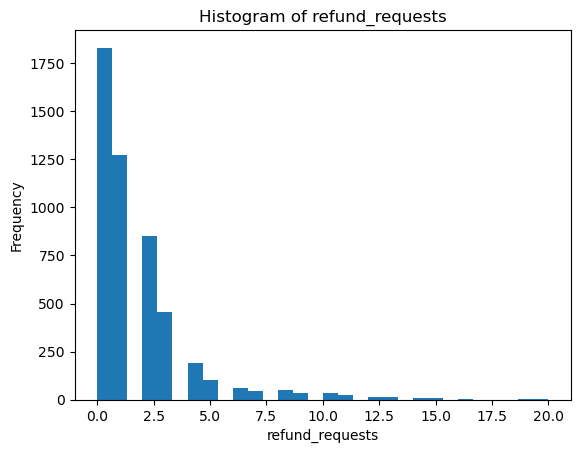

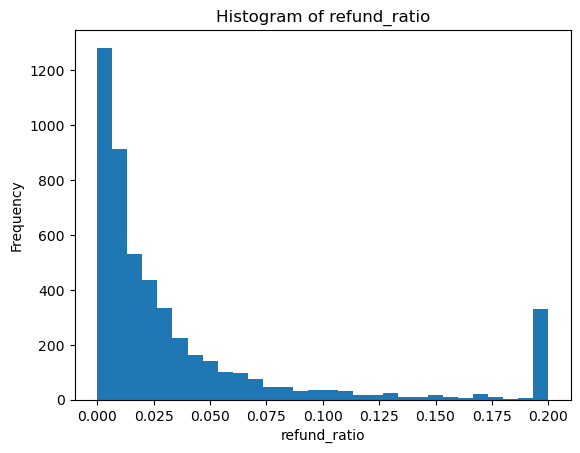

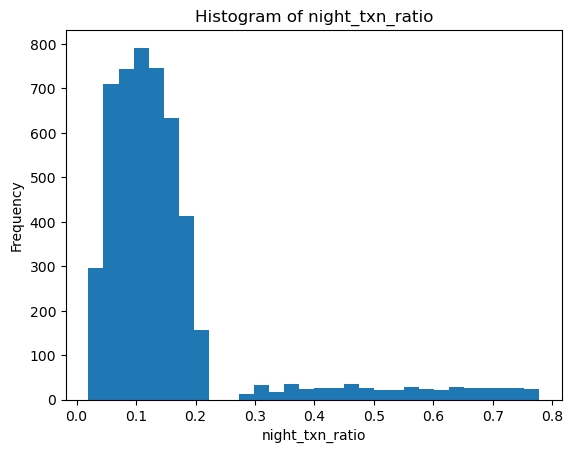

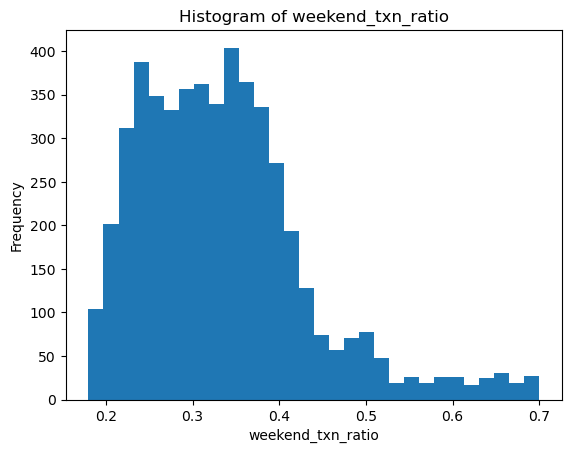

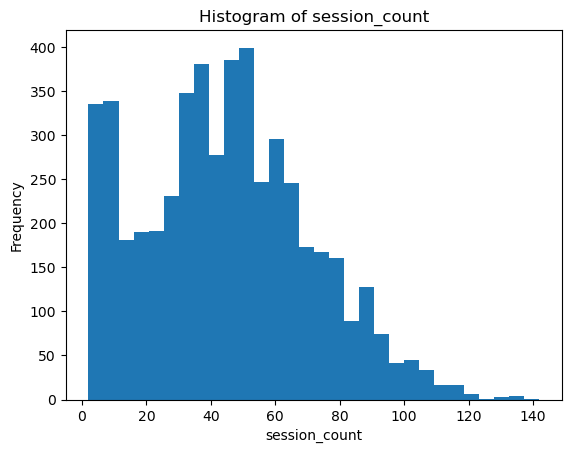

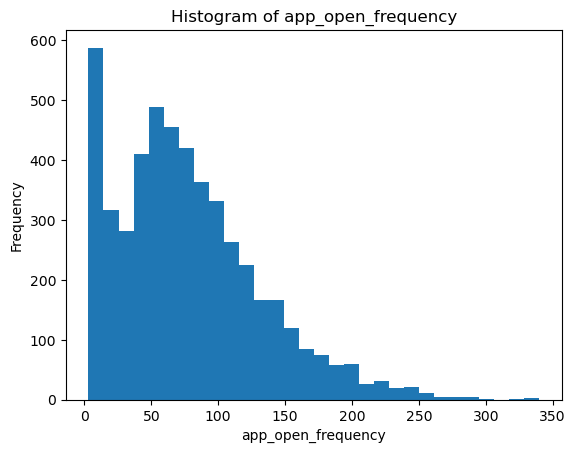

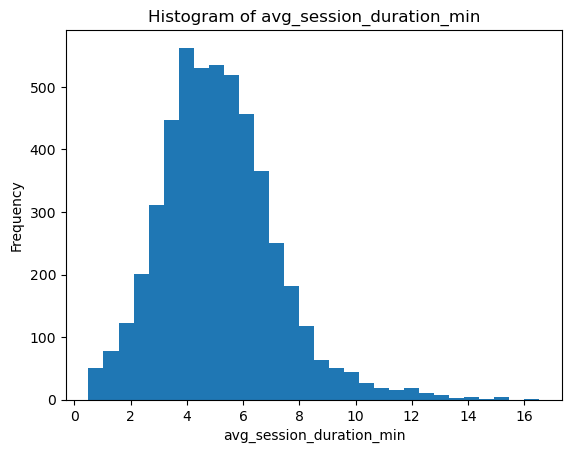

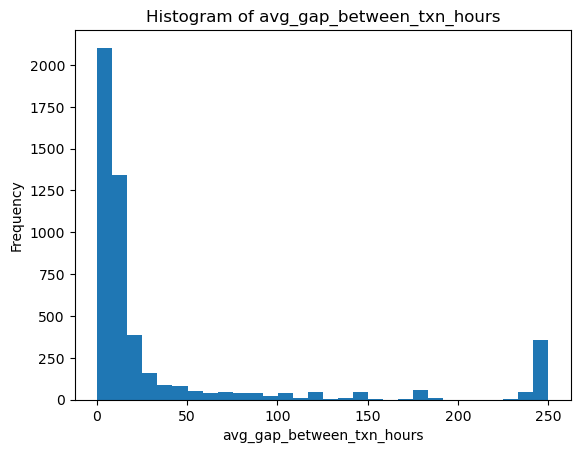

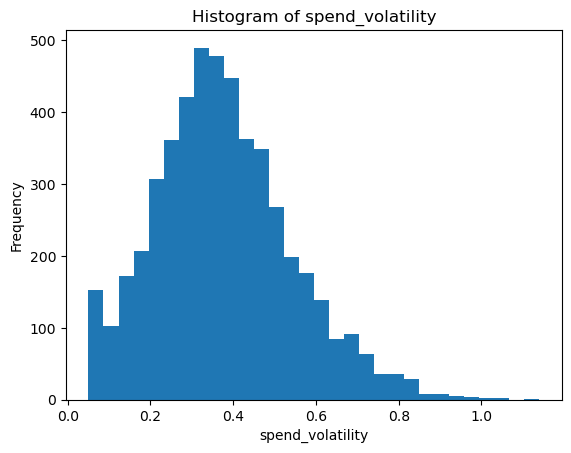

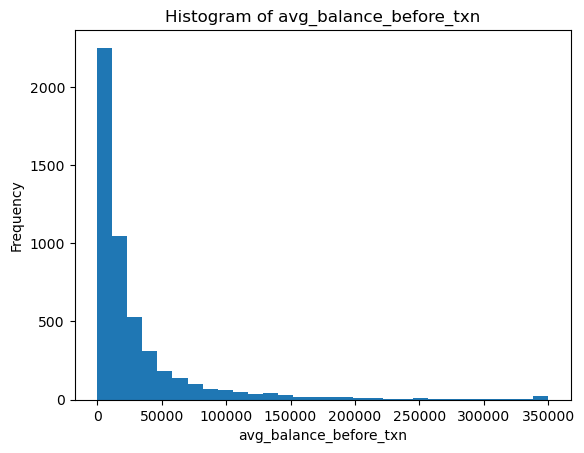

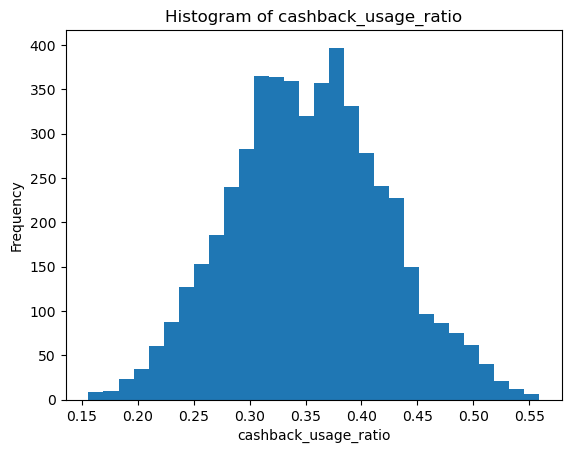

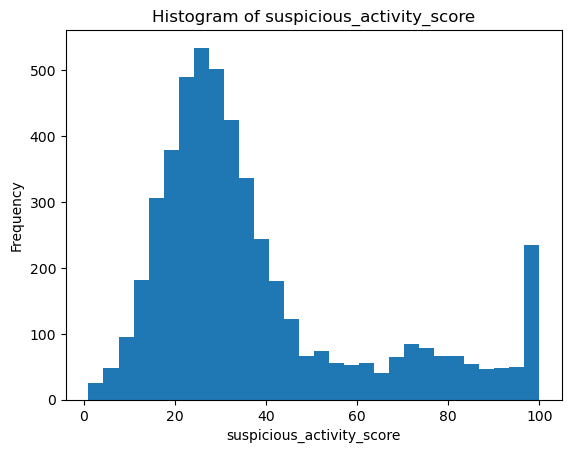

In [12]:
for col in numrical:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

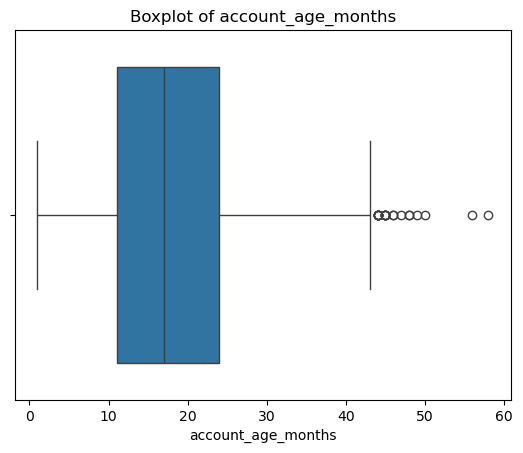

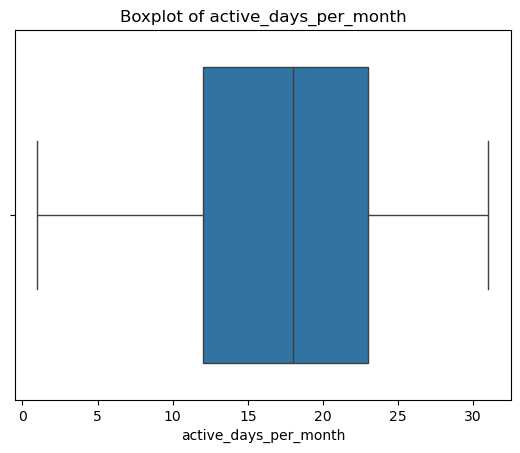

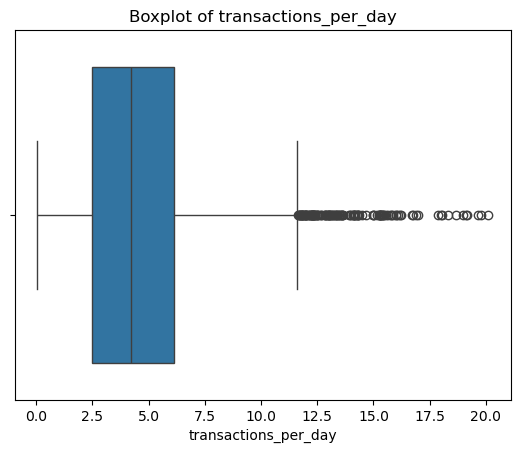

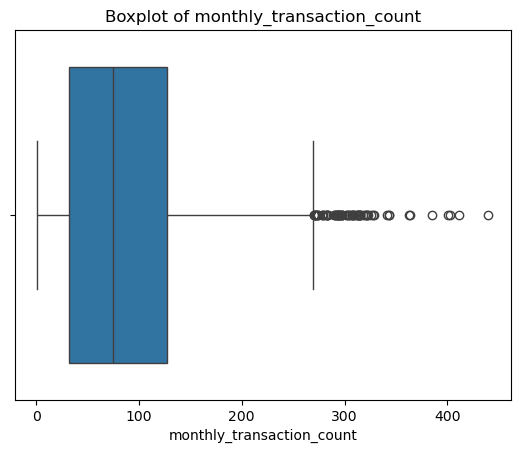

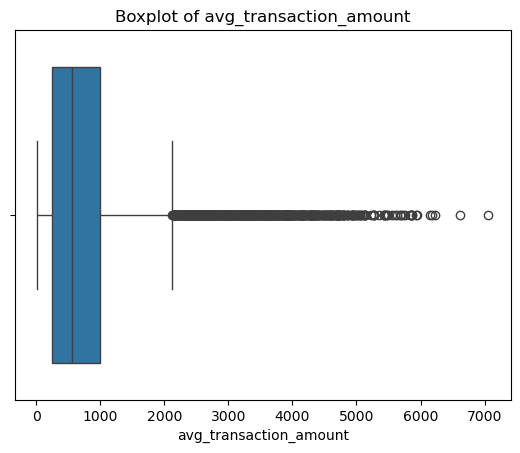

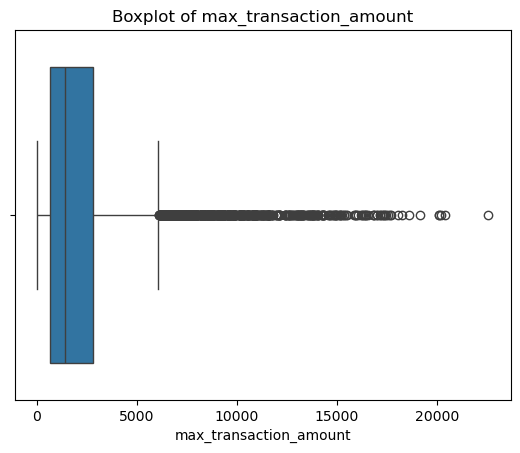

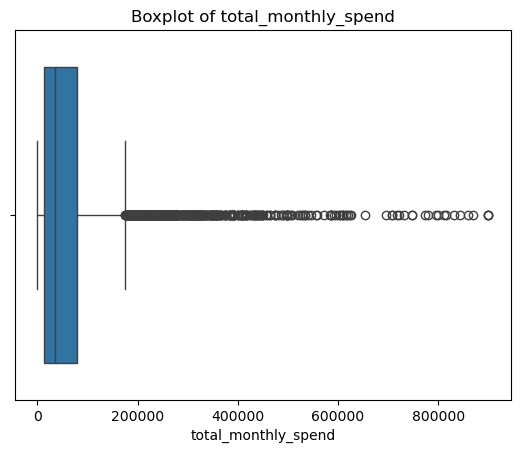

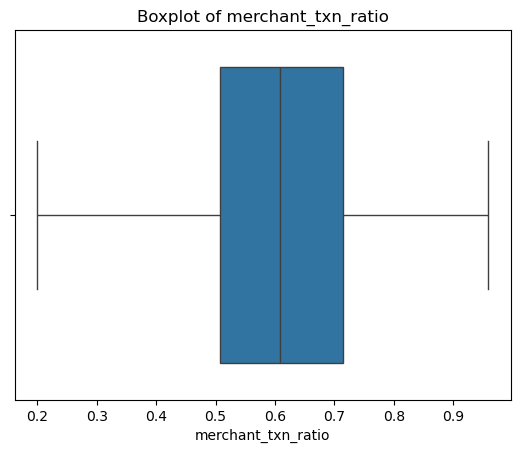

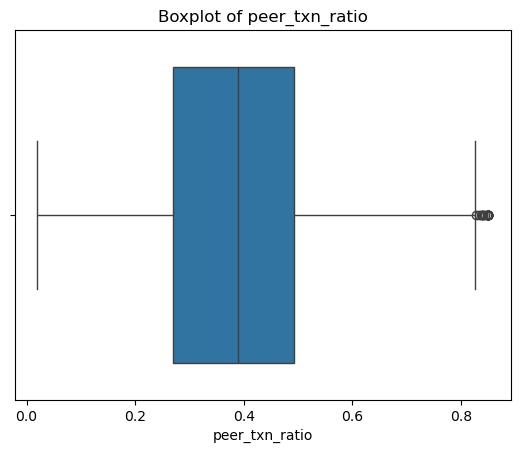

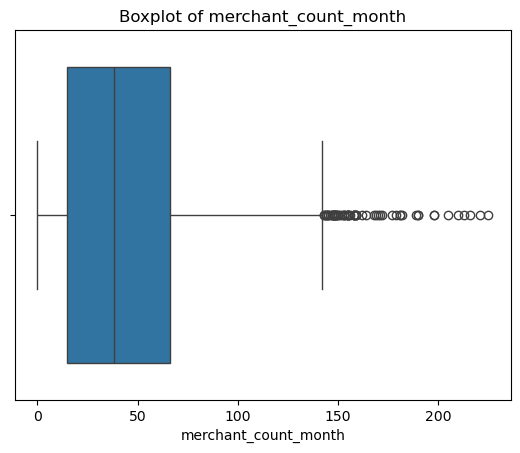

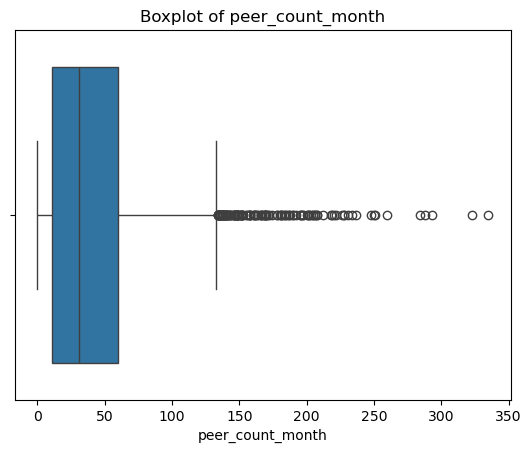

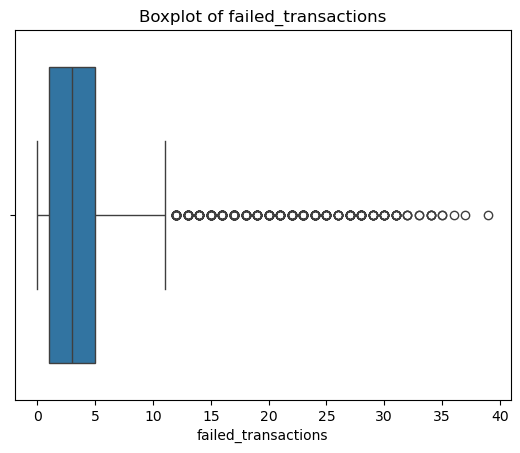

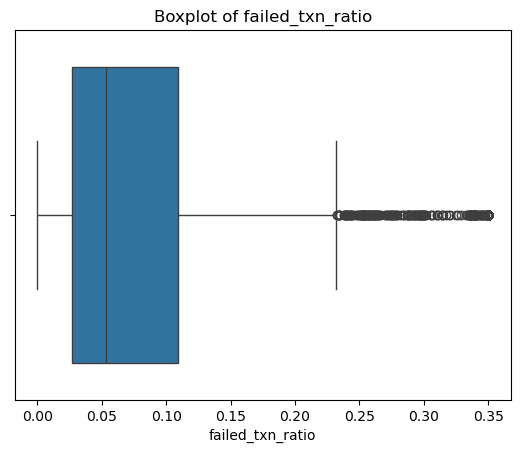

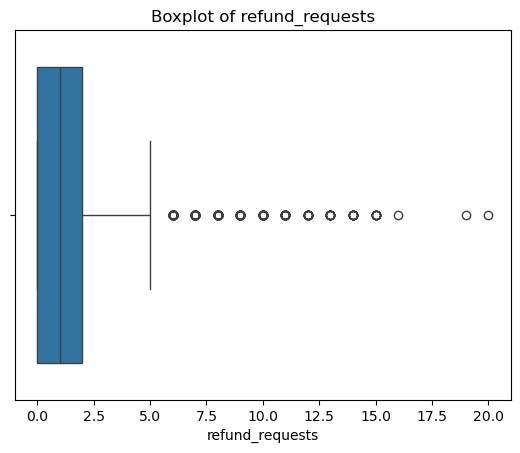

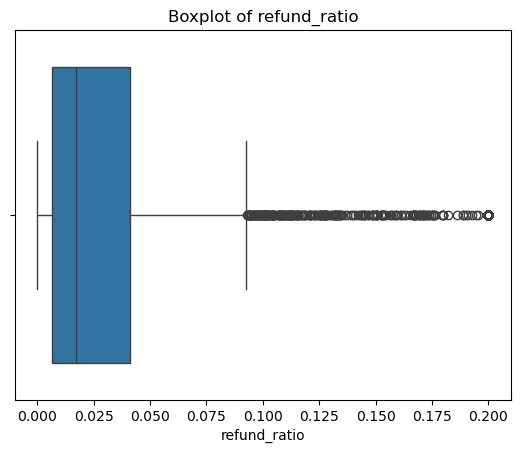

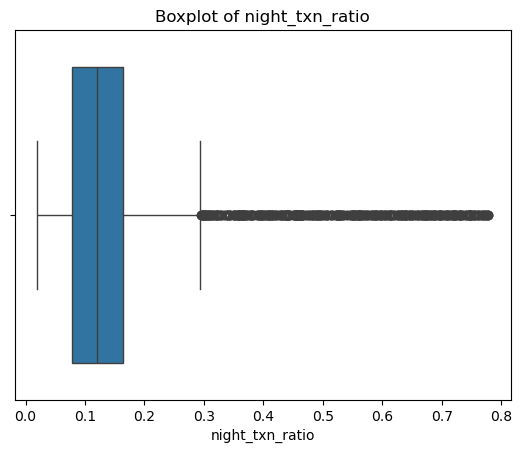

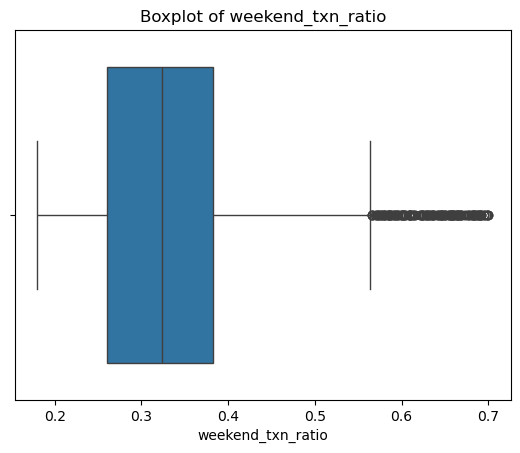

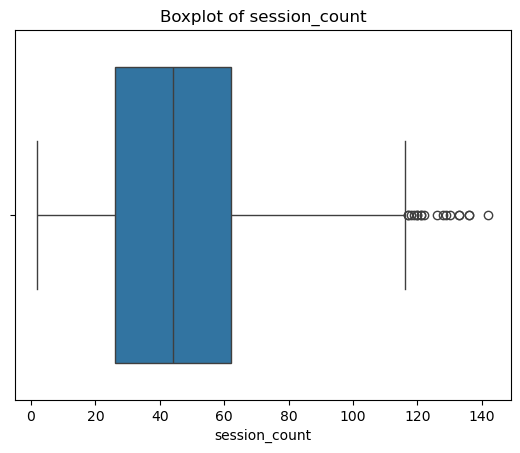

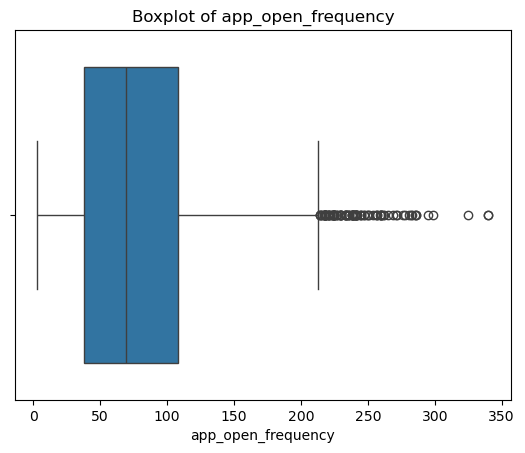

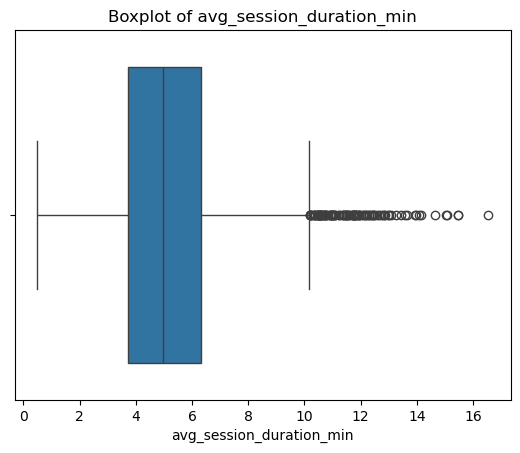

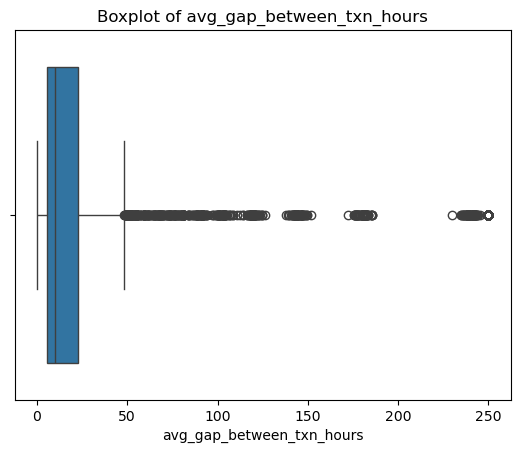

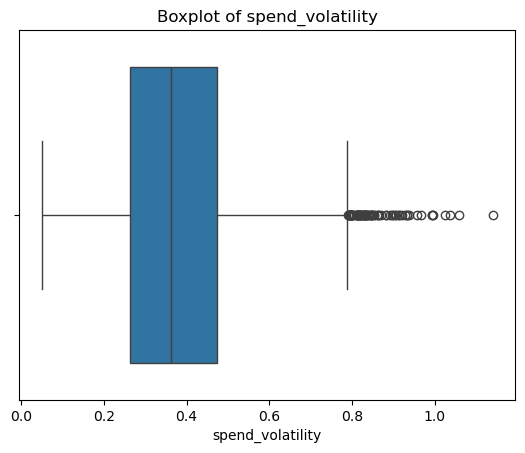

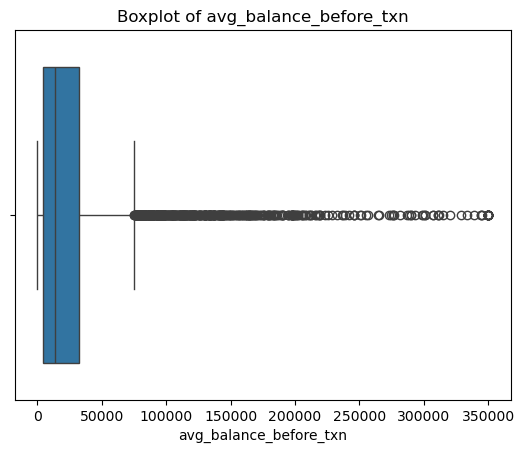

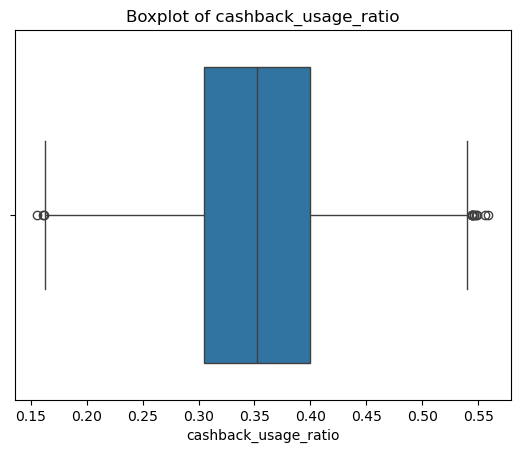

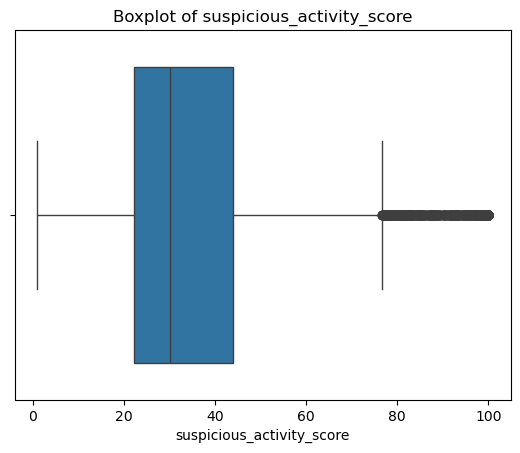

In [14]:
for col in numrical:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [19]:
category = [
'city',
 'device_type',
 'kyc_level',
 'account_age_band']

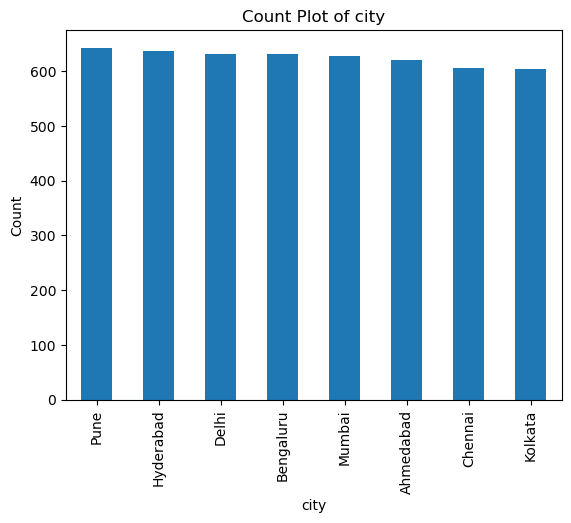

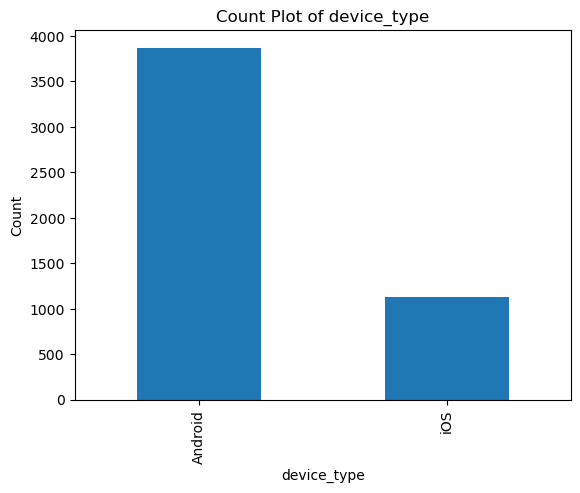

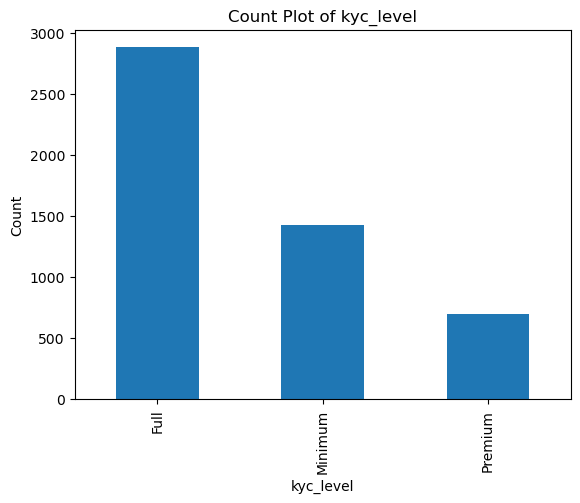

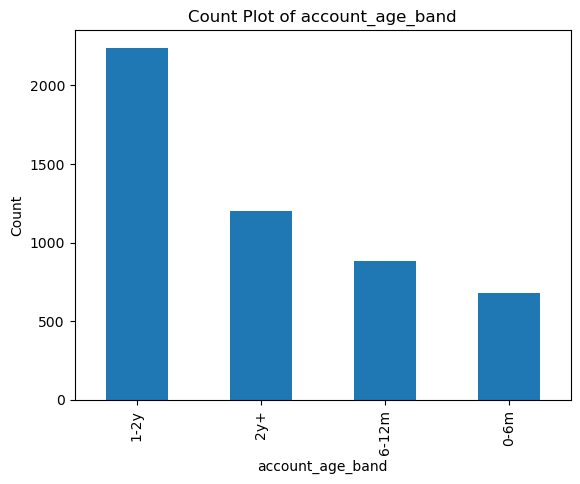

In [20]:
for col in category:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

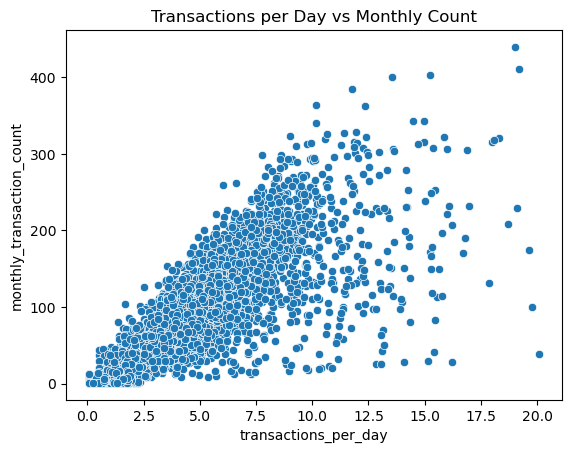

In [21]:
sns.scatterplot(x='transactions_per_day', y='monthly_transaction_count', data=df)
plt.title("Transactions per Day vs Monthly Count")
plt.show()

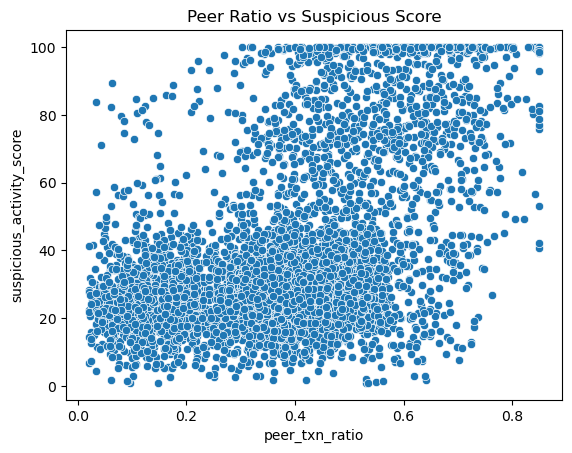

In [22]:
sns.scatterplot(x='peer_txn_ratio', y='suspicious_activity_score', data=df)
plt.title("Peer Ratio vs Suspicious Score")
plt.show()

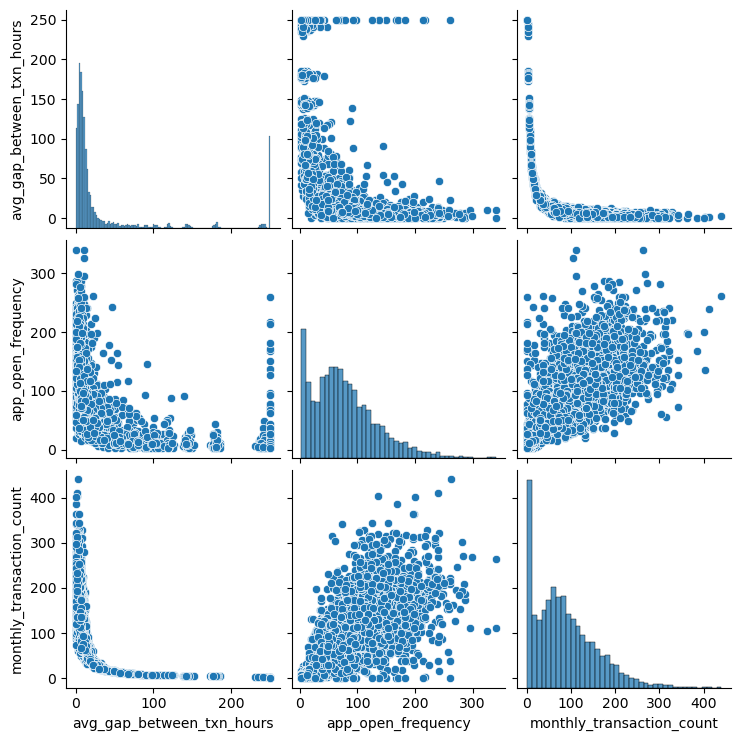

In [24]:
sns.pairplot(df[['avg_gap_between_txn_hours','app_open_frequency','monthly_transaction_count']])
plt.show()

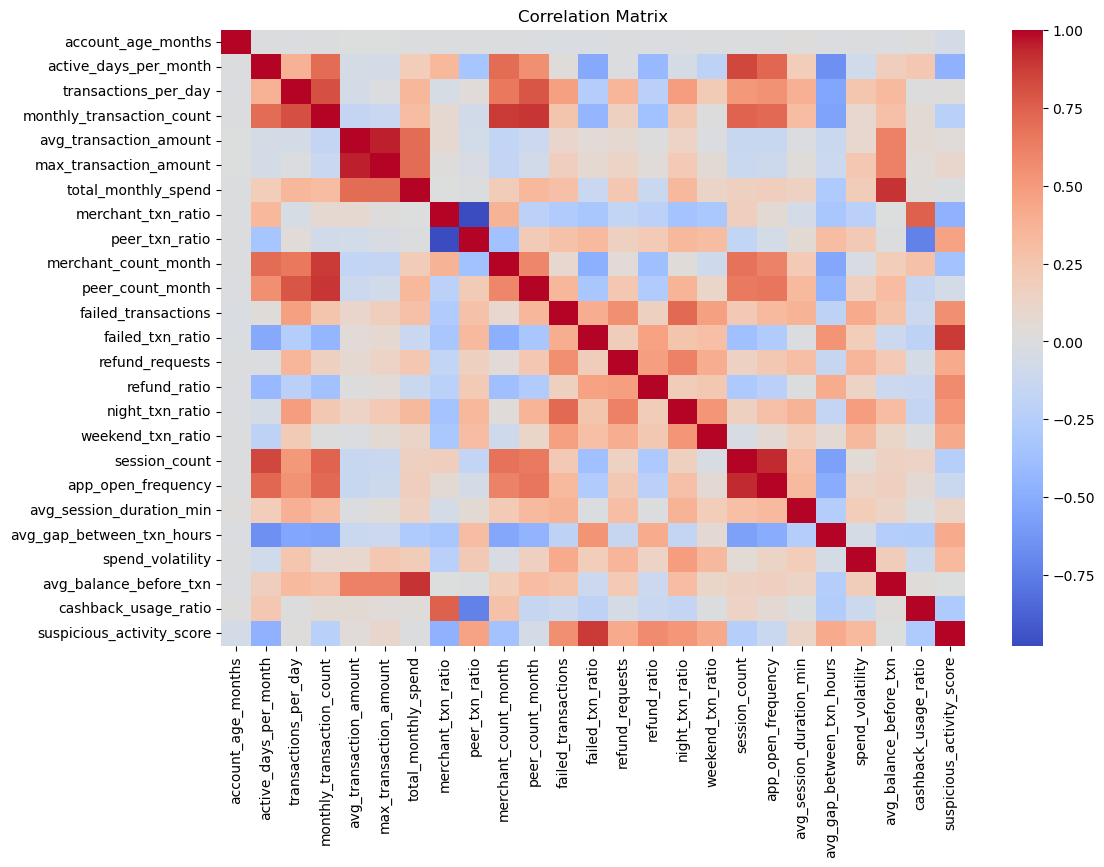

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [25]:
numerical_col=df.select_dtypes(include=['int64','float64'])

In [26]:
corr=numerical_col.corr()

In [27]:
corr

,account_age_months,active_days_per_month,transactions_per_day,monthly_transaction_count,avg_transaction_amount,max_transaction_amount,total_monthly_spend,merchant_txn_ratio,peer_txn_ratio,merchant_count_month,...,night_txn_ratio,weekend_txn_ratio,session_count,app_open_frequency,avg_session_duration_min,avg_gap_between_txn_hours,spend_volatility,avg_balance_before_txn,cashback_usage_ratio,suspicious_activity_score
account_age_months,1.000000,0.003666,-0.007725,-0.001293,0.005556,0.005964,0.000541,0.000779,0.001460,0.000265,...,-0.009728,-0.002299,0.000451,-0.000845,0.019754,-0.010187,0.002553,-0.004323,0.013466,-0.063562
active_days_per_month,0.003666,1.000000,0.378862,0.702211,-0.043700,-0.061567,0.193772,0.338258,-0.329808,0.704245,...,-0.043773,-0.204030,0.844962,0.725217,0.190820,-0.657615,-0.081426,0.179758,0.236158,-0.462274
transactions_per_day,-0.007725,0.378862,1.000000,0.813835,-0.060156,-0.009260,0.345764,-0.035539,0.035219,0.656012,...,0.489486,0.206115,0.510108,0.539856,0.384345,-0.539958,0.250946,0.322537,0.018466,0.021390
monthly_transaction_count,-0.001293,0.702211,0.813835,1.000000,-0.158738,-0.132124,0.307182,0.074558,-0.073758,0.883085,...,0.229137,0.019352,0.744714,0.715654,0.305553,-0.553128,0.091595,0.285478,0.063179,-0.229802
avg_transaction_amount,0.005556,-0.043700,-0.060156,-0.158738,1.000000,0.953427,0.700924,0.074408,-0.070222,-0.170319,...,0.139004,-0.003752,-0.142312,-0.138901,-0.006656,-0.119675,0.094932,0.621567,0.065870,0.038250
max_transaction_amount,0.005964,-0.061567,-0.009260,-0.132124,0.953427,1.000000,0.700277,0.022549,-0.020112,-0.165208,...,0.214668,0.058936,-0.125426,-0.107211,0.028172,-0.115867,0.237868,0.617225,0.035559,0.098432
total_monthly_spend,0.000541,0.193772,0.345764,0.307182,0.700924,0.700277,1.000000,0.005382,-0.001010,0.202770,...,0.328751,0.125312,0.158774,0.174197,0.147832,-0.282093,0.199656,0.900580,0.029599,0.002499
merchant_txn_ratio,0.000779,0.338258,-0.035539,0.074558,0.074408,0.022549,0.005382,1.000000,-0.976129,0.370933,...,-0.344062,-0.308234,0.176659,0.062286,-0.064676,-0.321475,-0.226241,0.006773,0.746173,-0.460206
peer_txn_ratio,0.001460,-0.329808,0.035219,-0.073758,-0.070222,-0.020112,-0.001010,-0.976129,1.000000,-0.361122,...,0.338625,0.307073,-0.170937,-0.057994,0.063527,0.311939,0.225157,-0.001499,-0.727261,0.459138
merchant_count_month,0.000265,0.704245,0.656012,0.883085,-0.170319,-0.165208,0.202770,0.370933,-0.361122,1.000000,...,0.034081,-0.094832,0.679236,0.612749,0.216469,-0.532026,-0.018944,0.190386,0.276992,-0.357410


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    5000 non-null   object 
 1   city                       5000 non-null   object 
 2   device_type                5000 non-null   object 
 3   kyc_level                  5000 non-null   object 
 4   account_age_months         5000 non-null   int64  
 5   account_age_band           5000 non-null   object 
 6   active_days_per_month      5000 non-null   int64  
 7   transactions_per_day       5000 non-null   float64
 8   monthly_transaction_count  5000 non-null   int64  
 9   avg_transaction_amount     5000 non-null   float64
 10  max_transaction_amount     5000 non-null   float64
 11  total_monthly_spend        5000 non-null   float64
 12  merchant_txn_ratio         5000 non-null   float64
 13  peer_txn_ratio             5000 non-null   float

In [28]:
drop_columns=[
    'user_id',
    'account_age_months',
    'merchant_count_month',
    'total_monthly_spend',
    'peer_count_month',
    'failed_transactions',
    'refund_requests'
]

In [32]:
catego_columns=[
    'city',
    'device_type',
    'kyc_level',
    'account_age_band'
]

In [33]:
num_features=[
    'suspicious_activity_score',
    'cashback_usage_ratio',
    'avg_balance_before_txn',
    'spend_volatility',
    'avg_gap_between_txn_hours',
    'avg_session_duration_min',
    'app_open_frequency',
    'session_count',
    'weekend_txn_ratio',
    'night_txn_ratio',
    'refund_requests',
    'failed_txn_ratio',
    'peer_txn_ratio',
    'merchant_txn_ratio',
    'max_transaction_amount',
    'avg_transaction_amount',
    'monthly_transaction_count',
    'active_days_per_month',
    'account_age_months'
]

In [34]:
df1=df.drop(columns=drop_columns)

In [35]:
df_encoded=pd.get_dummies(df1,columns=categorical_columns,drop_first=True)

In [36]:
X=df_encoded

In [37]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [38]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   active_days_per_month      5000 non-null   int64  
 1   transactions_per_day       5000 non-null   float64
 2   monthly_transaction_count  5000 non-null   int64  
 3   avg_transaction_amount     5000 non-null   float64
 4   max_transaction_amount     5000 non-null   float64
 5   merchant_txn_ratio         5000 non-null   float64
 6   peer_txn_ratio             5000 non-null   float64
 7   failed_txn_ratio           5000 non-null   float64
 8   refund_ratio               5000 non-null   float64
 9   night_txn_ratio            5000 non-null   float64
 10  weekend_txn_ratio          5000 non-null   float64
 11  session_count              5000 non-null   int64  
 12  app_open_frequency         5000 non-null   int64  
 13  avg_session_duration_min   5000 non-null   float

In [40]:
from sklearn.cluster import KMeans

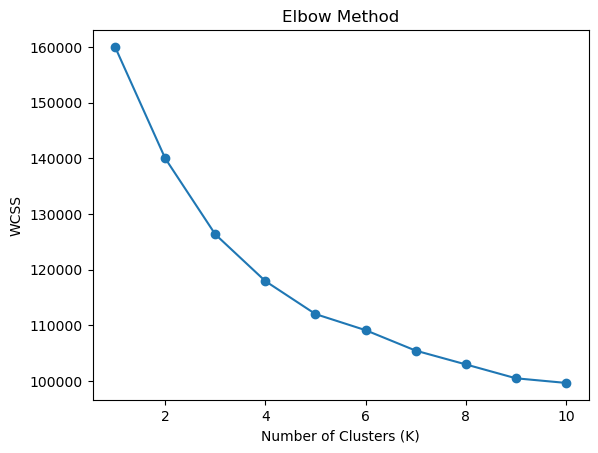

In [41]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure()
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [43]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X)

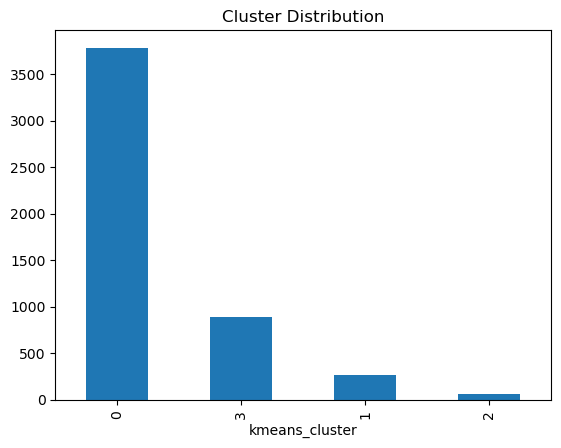

In [44]:
df['kmeans_cluster'].value_counts().plot(kind='bar')
plt.title("Cluster Distribution")
plt.show()

In [48]:
from sklearn.decomposition import PCA

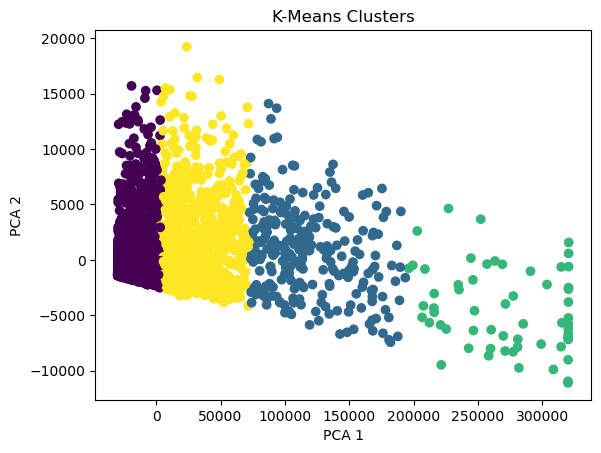

In [49]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['kmeans_cluster'])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters")
plt.show()

In [50]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=1.0,min_samples=10)
clusters=db.fit_predict(X_scaled)

In [51]:
df_encoded['DBSCAN_CLUSTER']=clusters
df_encoded['DBSCAN_CLUSTER'].value_counts()

DBSCAN_CLUSTER
-1    5000
Name: count, dtype: int64

In [52]:
outliers=df_encoded[df_encoded['DBSCAN_CLUSTER']==-1]

In [53]:
outliers.mean(numeric_only=True)

active_days_per_month           17.132200
transactions_per_day             4.571854
monthly_transaction_count       86.359400
avg_transaction_amount         953.655104
max_transaction_amount        2621.210372
merchant_txn_ratio               0.618921
peer_txn_ratio                   0.381818
failed_txn_ratio                 0.094197
refund_ratio                     0.037786
night_txn_ratio                  0.155231
weekend_txn_ratio                0.334804
session_count                   44.683800
app_open_frequency              77.741000
avg_session_duration_min         5.137040
avg_gap_between_txn_hours       38.024910
spend_volatility                 0.376452
avg_balance_before_txn       29765.524854
cashback_usage_ratio             0.353066
suspicious_activity_score       38.125814
city_Bengaluru                   0.126400
city_Chennai                     0.121200
city_Delhi                       0.126400
city_Hyderabad                   0.127200
city_Kolkata                     0

In [ ]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=3,linkage='ward')
clusters=hc.fit_predict(X)

In [63]:
df_encoded['HC_Cluster']=clusters

In [64]:
df_encoded['HC_Cluster'].value_counts()

HC_Cluster
-1    5000
Name: count, dtype: int64

In [65]:
from sklearn.decomposition import PCA

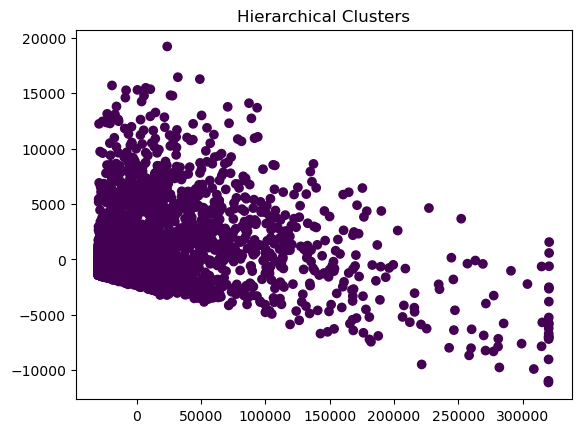

In [66]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
plt.figure()
plt.scatter(X_pca[:,0],X_pca[:,1],c=df_encoded['HC_Cluster'])
plt.title('Hierarchical Clusters')# Title
plt.show()